In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [3]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [4]:
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True) * 100)

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


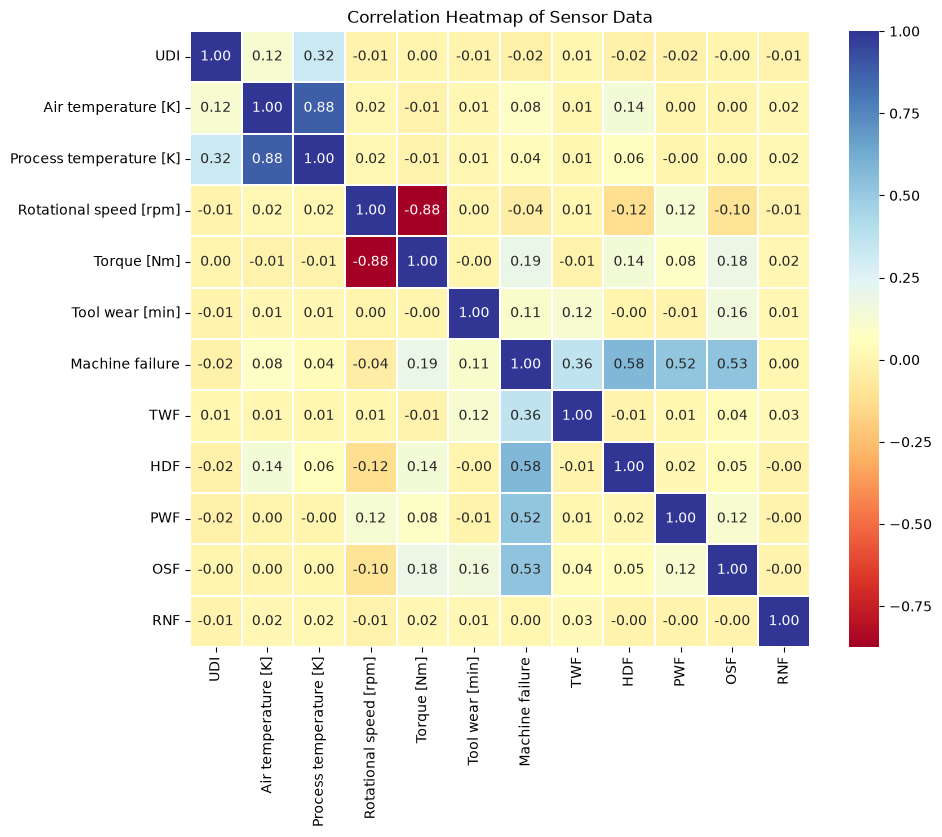

In [5]:
plt.figure(figsize=(10, 8))

corr_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', fmt='.2f', linewidths=0.2)
plt.title('Correlation Heatmap of Sensor Data')
plt.show()

In [6]:
#전처리 및 차원 축소

In [7]:
df.drop(['UDI', 'Product ID'], axis=1, inplace=True)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [8]:
#쓸모없는 찌꺼기 데이터(인덱스) 날리기

In [9]:

df = pd.get_dummies(df, drop_first=True)

print(df.columns)
df.head()

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_L',
       'Type_M'],
      dtype='str')


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


In [10]:
#범주형 데이터를 0과 1의 컬럼으로 변환 (One-Hot Encoding)
# drop_first=True를 주어 다중공선성(완벽한 상관관계)을 방지합니다.

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. 온도 관련 변수들만 따로 추출
temp_features = ['Air temperature [K]', 'Process temperature [K]']
X_temp = df[temp_features]

# 2. PCA는 데이터의 스케일에 민감하므로 먼저 표준화(StandardScaler) 진행
scaler = StandardScaler()
X_temp_scaled = scaler.fit_transform(X_temp)

# 3. 2개의 온도를 1개의 주성분(Principal Component)으로 압축
pca = PCA(n_components=1)
df['Temperature_PC1'] = pca.fit_transform(X_temp_scaled)

# 4. 기존에 중복되던 원본 온도 컬럼은 제거
df.drop(temp_features, axis=1, inplace=True)

# 결과 확인
df.head()

,Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M,Temperature_PC1
0,1551,42.8,0,0,0,0,0,0,0,False,True,-1.343326
1,1408,46.3,3,0,0,0,0,0,0,True,False,-1.260313
2,1498,49.4,5,0,0,0,0,0,0,True,False,-1.390985
3,1433,39.5,7,0,0,0,0,0,0,True,False,-1.307973
4,1408,40.0,9,0,0,0,0,0,0,True,False,-1.260313


In [12]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. 문제지(X)와 정답지(y) 분리
# 분석을 방해하는 5가지 개별 고장 모드(미래 데이터)도 문제지에서 과감히 제거합니다.
X = df.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df['Machine failure']

# 2. 데이터 쪼개기 (학습용 80% : 시험용 20%)
# stratify=y 는 쪼갤 때 3.4%라는 고장 비율을 양쪽에 공평하게 유지시켜 주는 필수 옵션입니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. SMOTE를 활용한 오버샘플링 (★오직 학습용 데이터인 X_train, y_train에만 적용)
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

# 4. 뻥튀기 결과 확인하기
print("기존 학습 데이터의 정상(0) 개수:", sum(y_train == 0))
print("기존 학습 데이터의 고장(1) 개수:", sum(y_train == 1))
print("--- SMOTE 적용 후 ---")
print("증폭된 학습 데이터의 정상(0) 개수:", sum(y_train_over == 0))
print("증폭된 학습 데이터의 고장(1) 개수:", sum(y_train_over == 1))

기존 학습 데이터의 정상(0) 개수: 7729
기존 학습 데이터의 고장(1) 개수: 271
--- SMOTE 적용 후 ---
증폭된 학습 데이터의 정상(0) 개수: 7729
증폭된 학습 데이터의 고장(1) 개수: 7729


In [13]:
# 셀 1: 랜덤 포레스트 모델 학습 및 예측
from sklearn.ensemble import RandomForestClassifier

# 1. 모델 준비 (n_estimators는 나무의 개수, random_state는 결과 고정용)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. 증폭된 데이터(SMOTE)로 모델 학습시키기
rf_model.fit(X_train_over, y_train_over)

# 3. 실전 모의고사(Test 데이터) 풀게 하기
y_pred = rf_model.predict(X_test)

print("모델 학습 및 예측 완료!")

모델 학습 및 예측 완료!


=== 분류 성능 평가 보고서 ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1932
           1       0.35      0.59      0.44        68

    accuracy                           0.95      2000
   macro avg       0.67      0.77      0.71      2000
weighted avg       0.96      0.95      0.96      2000



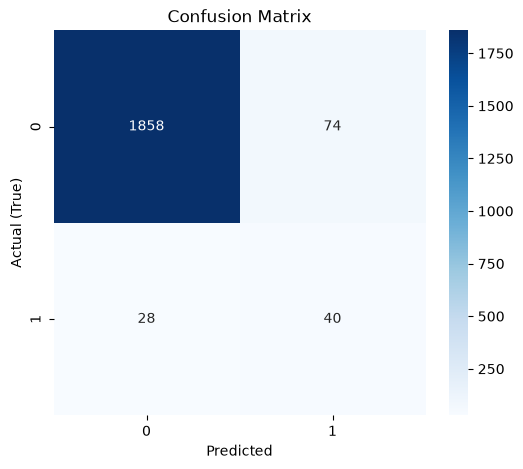

In [14]:
# 셀 2: 평가 지표 확인 및 혼동 행렬 시각화
from sklearn.metrics import classification_report, confusion_matrix

# 1. 상세 채점표 출력 (Precision, Recall, F1-score)
print("=== 분류 성능 평가 보고서 ===")
print(classification_report(y_test, y_pred))

# 2. 혼동 행렬(Confusion Matrix) 시각화
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
# annot=True로 숫자를 표기하고, cmap으로 색상 지정
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual (True)')
plt.xlabel('Predicted')
plt.show()

=== 임계값 0.3 적용 후 분류 성능 평가 ===
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1932
           1       0.30      0.78      0.43        68

    accuracy                           0.93      2000
   macro avg       0.65      0.86      0.70      2000
weighted avg       0.97      0.93      0.94      2000



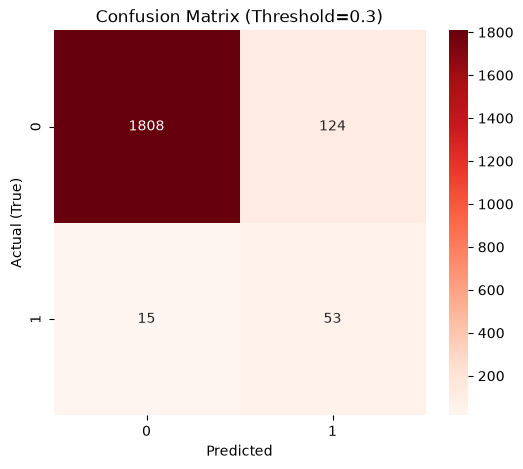

In [15]:
# 1. AI가 '고장(1)'이라고 판단한 확률값만 따로 추출
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# 2. 비즈니스 임계값(Threshold) 튜닝: 기본 50% -> 30%로 하향 조정
# 30%만 의심스러워도 선제적으로 고장 알람을 울리도록 설정하여 미탐지(FN)를 최소화
custom_threshold = 0.3
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

# 3. 튜닝 후 혼동 행렬 및 리포트 재확인
print("=== 임계값 0.3 적용 후 분류 성능 평가 ===")
print(classification_report(y_test, y_pred_custom))

cm_custom = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Reds') # 이전과 구분되도록 붉은색 테마 적용
plt.title('Confusion Matrix (Threshold=0.3)')
plt.ylabel('Actual (True)')
plt.xlabel('Predicted')
plt.show()

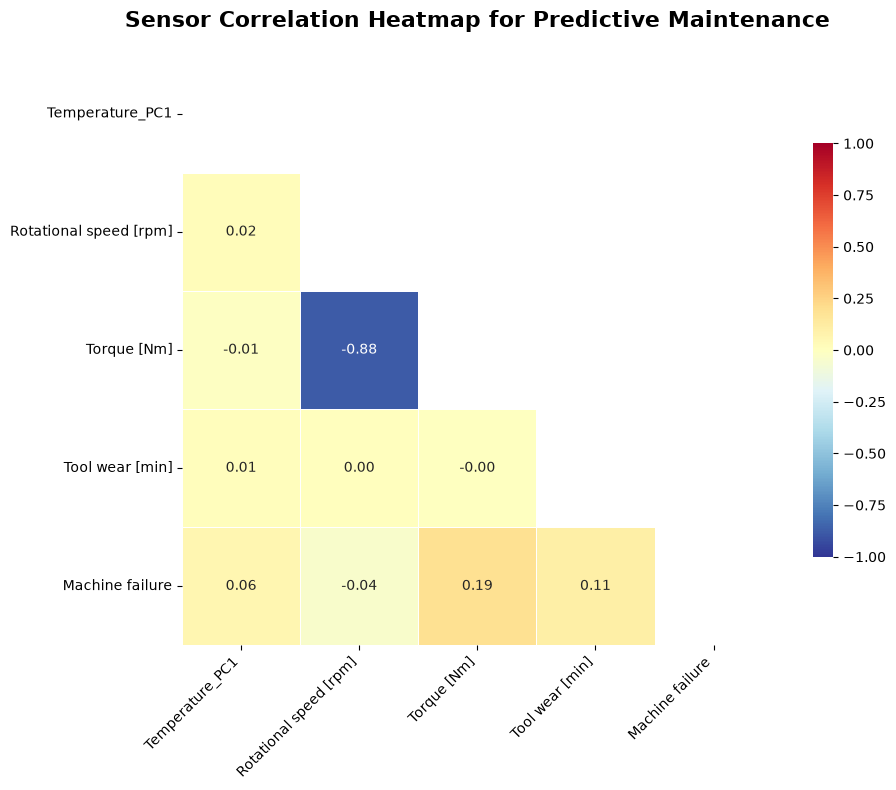

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 분석에 사용할 수치형 데이터만 추출 (PCA로 생성된 Temperature_PC1 반영)
# 현재 df에 존재하는 컬럼 이름들로 맞춤
numeric_cols = ['Temperature_PC1', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
df_numeric = df[numeric_cols]

# 2. 상관계수 행렬 계산
corr_matrix = df_numeric.corr()

# 3. 우상단 중복 데이터는 가리고 보기 좋게 마스킹
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. 고급 히트맵 시각화 렌더링
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdYlBu_r', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Sensor Correlation Heatmap for Predictive Maintenance', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import time
import re
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 핵심 해결책: LightGBM이 싫어하는 특수기호([, ])를 컬럼명에서 모두 제거
X_train_over.columns = [re.sub(r'[\[\]<>]', '', col) for col in X_train_over.columns]
X_test.columns = [re.sub(r'[\[\]<>]', '', col) for col in X_test.columns]

# 1. 평가할 모델 리스트 정의
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

# 2. 성능 측정을 위한 빈 데이터프레임 생성
performance_df = pd.DataFrame(columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Train Time(s)'])

# 3. 모델별 학습 및 평가 루프 실행
for model_name, model in models.items():
    start_time = time.time()
    
    # 학습
    model.fit(X_train_over, y_train_over)
    train_time = time.time() - start_time
    
    # 예측
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # 평가 지표 계산
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred_proba)
    
    # 결과 저장
    performance_df.loc[model_name] = [acc, prec, rec, f1, roc, train_time]

# 4. 결과 표 출력 (백분율 포맷팅 적용)
styled_performance = performance_df.style.background_gradient(cmap='coolwarm', subset=['F1-Score', 'ROC-AUC'])\
    .format({
        'Accuracy': '{:.2%}',
        'Precision': '{:.2%}',
        'Recall': '{:.2%}',
        'F1-Score': '{:.2%}',
        'ROC-AUC': '{:.2%}',
        'Train Time(s)': '{:.3f}'
    })

display(styled_performance)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time(s)
Logistic Regression,76.65%,8.52%,60.29%,14.94%,70.69%,0.079
Random Forest,94.90%,35.09%,58.82%,43.96%,95.10%,0.236
Gradient Boosting,91.85%,27.05%,82.35%,40.73%,95.00%,1.780
LightGBM,94.60%,33.87%,61.76%,43.75%,94.67%,0.585
